## New notebook to read output of MD simulation, using Adios2 library

### part 1: **print information summary + Read variables**

- Reading one of the sample output files (.bp), step by step.  
- Printing available variables and attributes, as well as their structure.

In [1]:
output_dir = "/home/hadis/custom_vector/buildParticleOriented/buildVS/archive/feb/feb13_phaseOr_LJphi2/outputs"
# output_dir = "/home/hadis/custom_vector/buildParticleOriented/buildVS/march4_aggregationData/outputs/equilibrated_0.2.bp"
# output_dir = "/home/hadis/custom_vector/runs/particleOriented/march7_testMoveCOM/outputs/run_0.bp"
# output_dir = "/home/hadis/custom_vector/buildParticleOriented/buildVS/march5_testEquilibration2/outputs/run_0.bp"
# output_dir = "/home/hadis/custom_vector/buildParticleOriented/buildVS/archive/feb/feb17_phaseOr_LJphi2/outputs/"
# output_dir= "/home/hadis/custom_vector/runs/particleOriented/march8_DLAmainClusterTest/outputs/run_0.bp"
# output_dir= "/home/hadis/custom_vector/runs/particleOriented/march9_testDLA/outputs/run_0.bp"
# output_dir= "/home/hadis/custom_vector/buildParticleOriented/buildVS/march4_aggregationData/initCluster/run_0.bp"
output_dir= "/home/hadis/custom_vector/runs/particleOriented/march12_testPara/outputs/aggregated_0.25_8.bp"

In [2]:
import numpy as np
from adios2 import Stream
import os

def print_output_file(file_path, print_summary=True):
    attributes = {}
    variables = {}

    with Stream(file_path, "r") as stream:
        for step_index, _ in enumerate(stream.steps()):
            if step_index == 0:
                for attr in stream.available_attributes():
                    attributes[attr] = stream.read_attribute(attr)

            for var in stream.available_variables():
                if var not in variables:
                    variables[var] = []
                variables[var].append(stream.read(var))

            if step_index > 10000:
                print("Warning: Too many steps, breaking the loop.")
                break    

    # Convert lists to numpy arrays
    for var in variables:
        variables[var] = np.array(variables[var])

    if print_summary:
        print("Attributes Summary:")
        print("-------------------")
        for idx, (name, value) in enumerate(attributes.items(), start=1):
            print(f"{idx}. {name:<40} {value}")

        print("\nVariables Summary:")
        print("------------------")
        for idx, (name, arr) in enumerate(variables.items(), start=1):
            shape = arr.shape
            description = f"{shape[0]} * {list(shape[1:])}" if arr.ndim > 1 else shape[0]
            print(f"{idx}. {name:<35} {description}")

    return {"attributes": attributes, "variables": variables}

def print_output_dir(output_dir, print_summary=True, index=0):
    file_path = os.path.join(output_dir, f"run_{index}.bp")
    if not os.path.isfile(file_path):
        raise FileNotFoundError(f"The file {file_path} does not exist.")
    return print_output_file(file_path, print_summary=print_summary)

# result = print_output_dir(output_dir, print_summary=True)

In [ ]:
import os
import re
import numpy as np
from adios2 import FileReader

def read_variable_directory(output_dir, variable_name):
    pattern = re.compile("run_([0-9]+).bp")
    run_numbers = [int(pattern.match(x)[1]) for x in os.listdir(output_dir) if pattern.match(x)]
    
    if not run_numbers:
        raise ValueError(f"No run files found in {output_dir}")
    
    run_numbers.sort()
    variable_data = []
    temperatures = []
    
    for i, run_num in enumerate(run_numbers):
        file_path = os.path.join(output_dir, f"run_{run_num}.bp")
        with FileReader(file_path) as reader:
            if variable_name in reader.available_variables():
                var_info = reader.available_variables()[variable_name]
                steps = int(var_info.get("AvailableStepsCount", 1))
    
                data = reader.read(variable_name, step_selection=[0, steps])
                if (data.ndim)== 1:
                    data = np.reshape(data, (1*steps, data.shape[0]//steps))
                else:
                    data = np.reshape(data, (1*steps, data.shape[0]//steps, data.shape[1]))

                variable_data.extend(data)
                
                temp_label = reader.read_attribute("temperature")
                temp_label = temp_label.flatten()
                temperatures.append(temp_label)
                
            else:
                raise ValueError(f"Variable {variable_name} not found in {file_path}")
    
    print(f'read {variable_name} successfully!')        
    return {'data':np.array(variable_data), 'temperature label':np.array(temperatures)}

def read_variable(output_file, variable_name):
    variable_data = []
    temperatures = []
    
    with FileReader(output_file) as reader:
        if variable_name in reader.available_variables():
            var_info = reader.available_variables()[variable_name]
            steps = int(var_info.get("AvailableStepsCount", 1))

            data = reader.read(variable_name, step_selection=[0, steps])
            if (data.ndim)== 1:
                data = np.reshape(data, (1*steps, data.shape[0]//steps))
            else:
                data = np.reshape(data, (1*steps, data.shape[0]//steps, data.shape[1]))

            variable_data.extend(data)
            
            temp_label = reader.read_attribute("temperature")
            temp_label = temp_label.flatten()
            temperatures.append(temp_label)
            
        else:
            raise ValueError(f"Variable {variable_name} not found in {output_file}")
    
    print(f'read {variable_name} successfully!')        
    return {'data':np.array(variable_data), 'temperature label':np.array(temperatures)}

def read_attributes(output_file, attribute_name):
    
    with FileReader(output_file) as reader:
        if attribute_name in reader.available_attributes():
            attribute_data = reader.read_attribute(attribute_name)
        else:
            raise ValueError(f"Variable {attribute_name} not found in {output_file}")
    
    print(f'{attribute_name} is {attribute_data}!')        
    return attribute_data


In [4]:
temperature=read_variable(output_dir, 'real temperature')
com_velocity=read_variable(output_dir, 'center of mass velocity')
com_ang_velocity=read_variable(output_dir, 'center of mass angular velocity')
kinetic_energy=read_variable(output_dir,'kinetic energy')
potential_energy=read_variable(output_dir,'potential energy')
orientational_order=read_variable(output_dir,'orientational order')
number_of_neighbors=read_variable(output_dir,'number of neighbors')
positions=read_variable(output_dir, 'positions')
# velocities=read_variable_directory(output_dir, 'velocities')

read real temperature successfully!
read center of mass velocity successfully!
read center of mass angular velocity successfully!
read kinetic energy successfully!
read potential energy successfully!
read orientational order successfully!
read number of neighbors successfully!
read positions successfully!


In [5]:
temperature=read_variable_directory(output_dir, 'real temperature')
com_velocity=read_variable_directory(output_dir, 'center of mass velocity')
com_ang_velocity=read_variable_directory(output_dir, 'center of mass angular velocity')
kinetic_energy=read_variable_directory(output_dir,'kinetic energy')
potential_energy=read_variable_directory(output_dir,'potential energy')
orientational_order=read_variable_directory(output_dir,'orientational order')
number_of_neighbors=read_variable_directory(output_dir,'number of neighbors')
positions=read_variable_directory(output_dir, 'positions')
# velocities=read_variable_directory(output_dir, 'velocities')

ValueError: No run files found in /home/hadis/custom_vector/runs/particleOriented/march12_testPara/outputs/aggregated_0.25_8.bp

In [6]:
read_attributes(output_dir, 'radius')

radius is 0.8!


0.8

In [7]:
import matplotlib.pyplot as plt

# plt.plot(np.sum(positions['data'][:,:,2], axis=1)/20, linestyle="none", marker="o")

In [8]:
# plt.plot(positions['data'][:20,2,2], linestyle="none", marker="o")

In [9]:
# plt.plot(velocities['data'][:,2,2])

---

### Part 2: **Plot system properties**:
- Energy Evolution
- Temperature Evolution
- Number of Neighbors
- Order Parameter
- Center of Mass Velocity

In [10]:
import numpy as np
import matplotlib.pyplot as plt


def plot_temperature(m_temperatures, temperature_label=True):
    temperature_data = m_temperatures['data']
    temp_labels = m_temperatures['temperature label']
    fig, ax = plt.subplots(figsize=(7, 4))
    
    ax.grid(True, linestyle='--', alpha=0.7, color='gray')

    colors = plt.cm.plasma(np.linspace(0, 1, 4))
    axis_labels = ['x', 'y', r'$\omega$']

    for i, axis_label in enumerate(axis_labels):
        ax.plot(temperature_data[:, :, i], label=f"T{axis_label}", color=colors[i])
    
    if temperature_label: 
        total_points = temperature_data.shape[0]
        tick_indices = np.linspace(0, total_points - 1, 10, dtype=int)
        label_indices = np.linspace(0, len(temp_labels) - 1, 10, dtype=int)
        ax.set_xlabel("Temperature")
        ax.set_xticks(tick_indices)
        ax.set_xticklabels([f"T={temp_labels[i][0]:.1f}" for i in label_indices], rotation=45)
    else:
        ax.set_xlabel("Steps")

                
    ax.set_ylabel("Measured Temperature")
    ax.set_title("Temperature Evolution")
    
    ax.legend(bbox_to_anchor=(1, 1), loc='upper left', frameon=True, fancybox=True, shadow=False)
    
    plt.tight_layout()
    plt.show()

def plot_neighbors(neighbors_array, m_temperatures, temperature_show=False, temperature_label=True):
    neighbors_data = neighbors_array['data']
    temp_labels = neighbors_array['temperature label']
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.grid(True, linestyle='--', alpha=0.7, color='gray')

    colors = plt.cm.viridis(np.linspace(0, 1, 4))

    for i in range(neighbors_data.shape[2]):
        ax.plot(neighbors_data[:, :, i], label=f"Shell {i+1}", color=colors[i], linewidth=2)


    if temperature_label: 
        total_points = neighbors_data.shape[0]
        tick_indices = np.linspace(0, total_points - 1, 10, dtype=int)
        label_indices = np.linspace(0, len(temp_labels) - 1, 10, dtype=int)
        ax.set_xlabel("Temperature")
        ax.set_xticks(tick_indices)
        ax.set_xticklabels([f"T={temp_labels[i][0]:.1f}" for i in label_indices], rotation=45)
    else:
        ax.set_xlabel("Steps")

    ax.set_ylabel("Number of Neighbors")
    ax.set_title("Neighbor Analysis")
    
    ax.legend(bbox_to_anchor=(1, 1), loc='upper left', frameon=True, fancybox=True, shadow=False)

    plt.tight_layout()
    plt.show()

    if temperature_show:
        plot_temperature(m_temperatures)

def plot_energies(kinetic_energy, potential_energy, m_temperatures, show_potential=True, temperature_show=False, temperature_label=True):
    kinetic_energy_data = kinetic_energy['data']
    temp_labels = kinetic_energy['temperature label']
    potential_energy_data = potential_energy['data'] / 40

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.grid(True, linestyle='--', alpha=0.7, color='gray')

    colors = plt.cm.plasma(np.linspace(0, 1, kinetic_energy_data.shape[2] + 3))
    axis_labels = ['x', 'y', r'$\omega$']

    for i, axis_label in enumerate(axis_labels):
        ax.plot(kinetic_energy_data[:, :, i], label=f"K{axis_label}", color=colors[i])

    if show_potential:
        y2 = potential_energy_data.flatten()
        ax.plot(y2, label='U', color=colors[3])
        ax.plot(y2 + np.sum(kinetic_energy_data, axis=2)[:, 0], label='Total', color=colors[4])

    if temperature_label: 
        total_points = potential_energy_data.shape[0]
        tick_indices = np.linspace(0, total_points - 1, 10, dtype=int)
        label_indices = np.linspace(0, len(temp_labels) - 1, 10, dtype=int)
        ax.set_xlabel("Temperature")
        ax.set_xticks(tick_indices)
        ax.set_xticklabels([f"T={temp_labels[i][0]:.1f}" for i in label_indices], rotation=45)
    else:
        ax.set_xlabel("Steps")

    ax.set_ylabel("Energy")
    ax.set_title("Energy Evolution")
    
    ax.legend(bbox_to_anchor=(1, 1), loc='upper left', frameon=True, fancybox=True, shadow=False)

    plt.tight_layout()
    plt.show()

    if temperature_show:
        plot_temperature(m_temperatures)

def plot_com_velocity(com_velocity, m_temperatures, temperature_show=False, temperature_label=True):
    com_vel_data = com_velocity['data']
    temp_labels = com_velocity['temperature label']
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.grid(True, linestyle='--', alpha=0.7, color='gray')

    colors = plt.cm.plasma(np.linspace(0, 1, 4))
    axis_labels = ['x', 'y']

    for i, axis_label in enumerate(axis_labels):
        ax.plot(com_vel_data[:, :, i], label=f"K{axis_label}", color=colors[i])

    if temperature_label: 
        total_points = com_vel_data.shape[0]
        tick_indices = np.linspace(0, total_points - 1, 10, dtype=int)
        label_indices = np.linspace(0, len(temp_labels) - 1, 10, dtype=int)
        ax.set_xlabel("Temperature")
        ax.set_xticks(tick_indices)
        ax.set_xticklabels([f"T={temp_labels[i][0]:.1f}" for i in label_indices], rotation=45)
    else:
        ax.set_xlabel("Steps")

    ax.set_ylabel("Velocity")
    ax.set_title("Center of Mass Velocity Evolution")
    
    ax.legend(bbox_to_anchor=(1, 1), loc='upper left', frameon=True, fancybox=True, shadow=False)

    plt.tight_layout()
    plt.show()

    if temperature_show:
        plot_temperature(m_temperatures)

def plot_com_ang_velocity(com_ang_velocity, m_temperatures, temperature_show=False, temperature_label=True):
    data = kinetic_energy['data']
    temp_labels = kinetic_energy['temperature label']
    data = com_ang_velocity['data'] / 100

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.grid(True, linestyle='--', alpha=0.7, color='gray')

    y2 = data.flatten()
    ax.plot(y2, color='#b47c39')

    if temperature_label: 
        total_points = data.shape[0]
        tick_indices = np.linspace(0, total_points - 1, 10, dtype=int)
        label_indices = np.linspace(0, len(temp_labels) - 1, 10, dtype=int)
        ax.set_xlabel("Temperature")
        ax.set_xticks(tick_indices)
        ax.set_xticklabels([f"T={temp_labels[i][0]:.1f}" for i in label_indices], rotation=45)
    else:
        ax.set_xlabel("Steps")

    ax.set_ylabel("Angular Velocity")
    ax.set_title("Center of Mass Angular Velocity Evolution")
    
    plt.tight_layout()
    plt.show()

    if temperature_show:
        plot_temperature(m_temperatures)
        
def plot_order_parameter(order, m_temperatures, type, temperature_show=False, temperature_label=True):
    order_data = order['data']
    temp_labels = order['temperature label']
    fig, ax = plt.subplots(figsize=(6, 3.8))  
    
    ax.grid(True, linestyle='--', alpha=0.7, color='gray')
    ax.plot(order_data[:, :], color='#5499C7')

    if temperature_label: 
        total_points = order_data.shape[0]
        tick_indices = np.linspace(0, total_points - 1, 10, dtype=int)
        label_indices = np.linspace(0, len(temp_labels) - 1, 10, dtype=int)
        ax.set_xlabel("Temperature")
        ax.set_xticks(tick_indices)
        ax.set_xticklabels([f"T={temp_labels[i][0]:.1f}" for i in label_indices], rotation=45)
    else:
        ax.set_xlabel("Steps")

    ax.set_ylabel("Order Parameter")
    ax.set_title(f"{type} Order Parameter")
        
    plt.tight_layout()
    plt.show()

    if temperature_show:
        plot_temperature(m_temperatures)


In [11]:
# edit later >> add x axis as particles numbers for deposition 
 
# particle_num = np.sum(~np.isnan(positions['data'][0, :, 0]))
# np.sum(~np.isnan(positions['data'][14100, :, 0]))

def plot_neighbors_aggregation(neighbors_array, positions):
    neighbors_data = neighbors_array['data']
    temp_labels = neighbors_array['temperature label']
    total_steps_pos = positions['data'].shape[0]
    
    particle_num_list=[]
    num_label = 10
    for i in range(num_label):
        particle_num_list.append(np.sum(~np.isnan(positions['data'][(total_steps_pos//num_label)*i, :, 0])))
    
    particle_num_list = [np.sum(~np.isnan(positions['data'][i, :, 0])) for i in range(total_steps_pos)]

    print(particle_num_list)
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.grid(True, linestyle='--', alpha=0.7, color='gray')

    colors = plt.cm.viridis(np.linspace(0, 1, 4))

    for i in range(neighbors_data.shape[2]):
        ax.plot(neighbors_data[:, :, i], label=f"Shell {i+1}", color=colors[i], linewidth=2)

    ax.set_xticks(particle_num_list)
    ax.set_xticklabels([f"N={particle_num_list[i]}" for i in particle_num_list], rotation=45)

    ax.set_ylabel("Number of Neighbors")
    ax.set_title(f"Neighbor Analysis aggregated at temperature = {temp_labels[0][0]}")
    
    ax.legend(bbox_to_anchor=(1, 1), loc='upper left', frameon=True, fancybox=True, shadow=False)

    plt.tight_layout()
    plt.show()
    
# plot_neighbors_aggregation(number_of_neighbors, positions)

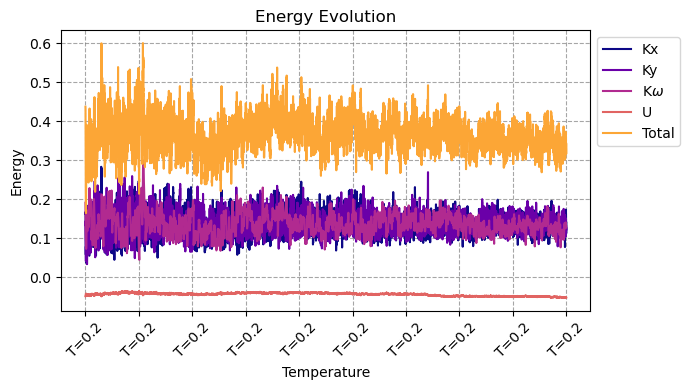

In [12]:
plot_energies(kinetic_energy, potential_energy, temperature, show_potential=True, temperature_label=True)

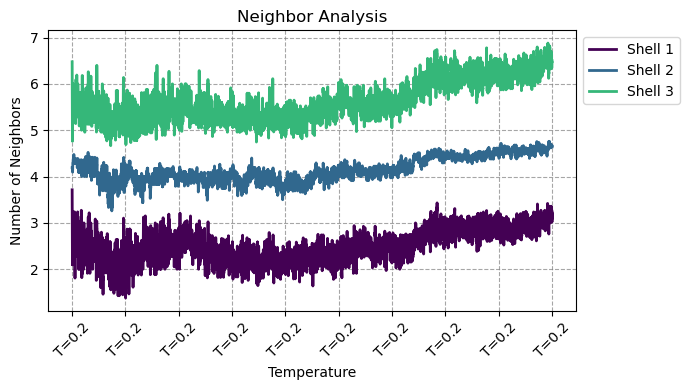

In [13]:
plot_neighbors(number_of_neighbors, temperature, temperature_label=True)

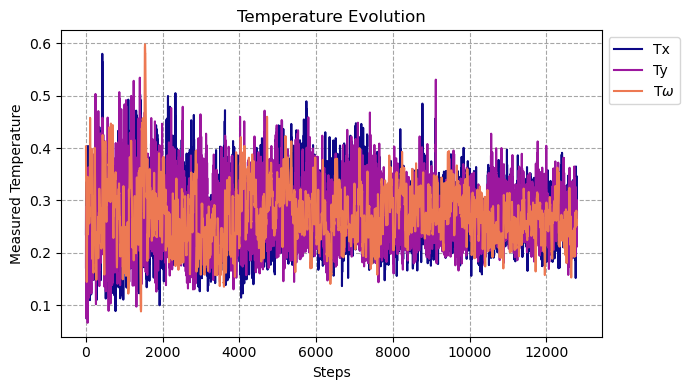

In [14]:
plot_temperature(temperature, temperature_label=False)

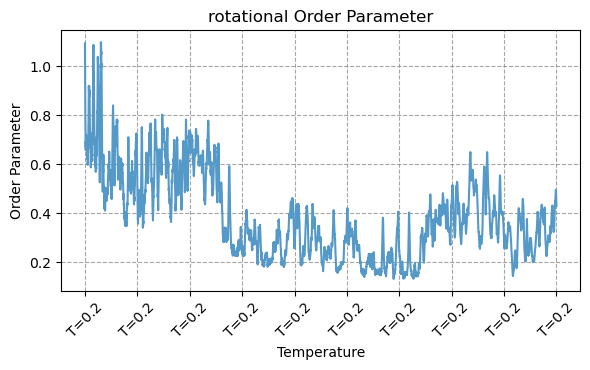

In [15]:
plot_order_parameter(orientational_order, temperature, "rotational", temperature_label=True)

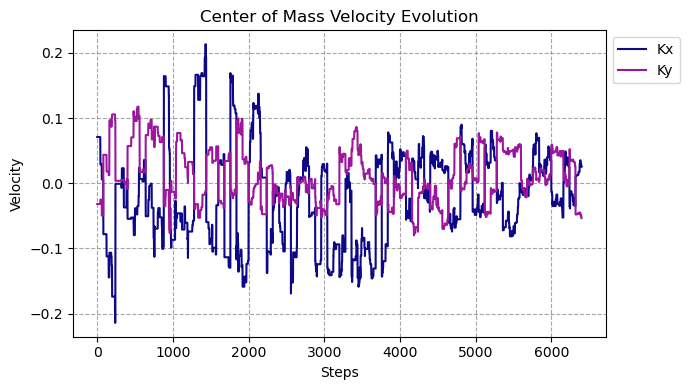

In [16]:
plot_com_velocity(com_velocity, temperature, temperature_label=False)

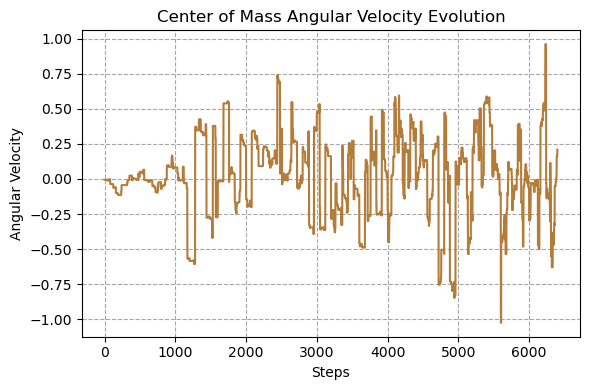

In [17]:
plot_com_ang_velocity(com_ang_velocity, temperature, temperature_label=False)

---

### Part 3: **|. Snapshots of system configuration For DLA Aggregation**

available steps:  64000 	choosed step:  -1


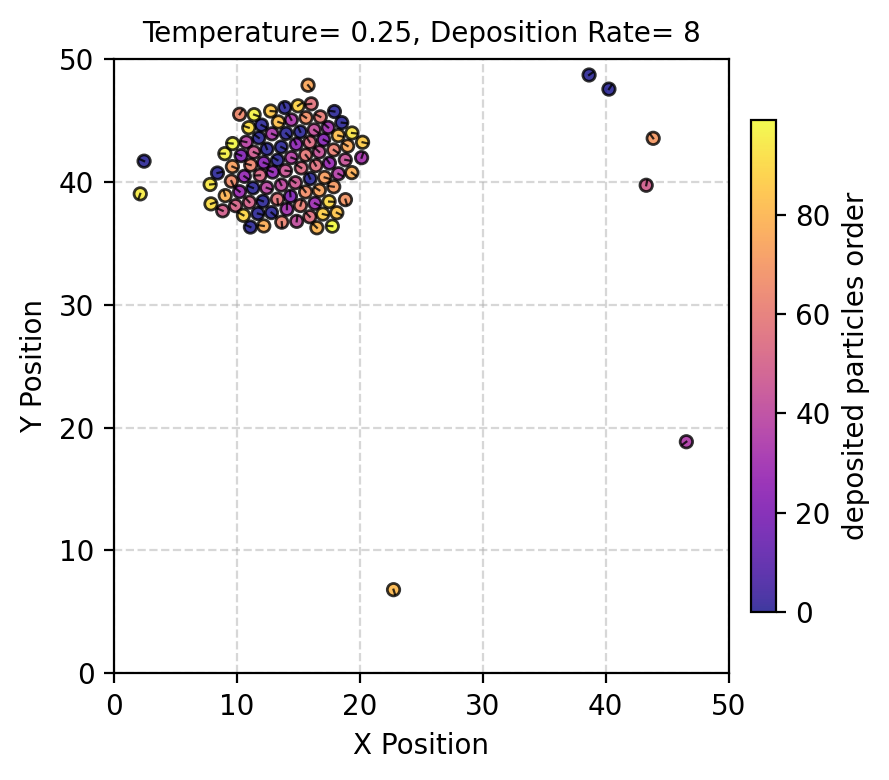

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def plot_position_snapshot_aggregation(positions, shot=-1, line_length=0.4, area=50, color_p=False, diameter=1.6, deposition_rate=.1, x_limit=(0, 50),y_limit=(0, 50), save_fig=False):

    x0, x1 = x_limit
    y0, y1 = y_limit
        
    positions_data = positions['data']
    availble_shot = positions_data.shape[0]
    print('available steps: ', availble_shot, '\tchoosed step: ', shot)

    x = positions_data[shot, :, 0]
    y = positions_data[shot, :, 1]
    if positions_data.shape[2] == 3:
        phi = positions_data[shot, :, 2]

    T = positions["temperature label"][0][0]
    t = deposition_rate
    
    fig, ax = plt.subplots(figsize=(6, 4), dpi=200)

    if positions_data.shape[2] == 3:
        if color_p:
            scatter = ax.scatter(
                x, y, 
                s=diameter,
                c=phi,
                cmap='twilight',
                alpha=0.8
            )
            cbar = fig.colorbar(scatter, ax=ax, label='Phi (radians)', orientation='vertical', shrink=0.8, pad=0.02)
            cbar.set_alpha(1)
        else:
            
            colors = np.arange(len(x))
            colors[:20] = 0
            
            scatter = ax.scatter(
                x, y, 
                s=diameter,
                edgecolors='black',
                facecolors='none',
                alpha=0.8,
                cmap='plasma',
                c=colors
            )
            x_end = x + line_length * np.cos(phi)
            y_end = y + line_length * np.sin(phi)
            cbar = fig.colorbar(scatter, ax=ax, label='deposited particles order', orientation='vertical', shrink=0.8, pad=0.02)

            
            for i in range(positions_data.shape[1]):
                ax.plot([x[i], x_end[i]], [y[i], y_end[i]], color='black', linewidth=0.8, alpha=0.8)

    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    # if shot == -1:
    #     ax.set_title(f"Particle's configuration at the last step out of {availble_shot}")
    # elif shot == 0:
    #     ax.set_title(f"Particle's configuration at the first step out of {availble_shot}")
    # else:
    #     ax.set_title(f"Particle's configuration at step {shot} out of {availble_shot}")
    ax.set_title(f"Temperature= {T}, Deposition Rate= {t}", size=10)

    ax.set_xlim(0, area)
    ax.set_ylim(0, area)
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    # ax.set_xlim(10, 40)
    # ax.set_ylim(10, 40)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

    plt.tight_layout()
    if save_fig:
        plt.savefig(f'aggregated_{T}_{t}.pdf')
    plt.show()
    
# plot_position_snapshot_aggregation(positions, shot=-1, area=30, color_p=True)
plot_position_snapshot_aggregation(positions, shot=-1, area=50, color_p=False, line_length=0.4, diameter=20, deposition_rate=8)

available steps:  64000 	choosed step:  0


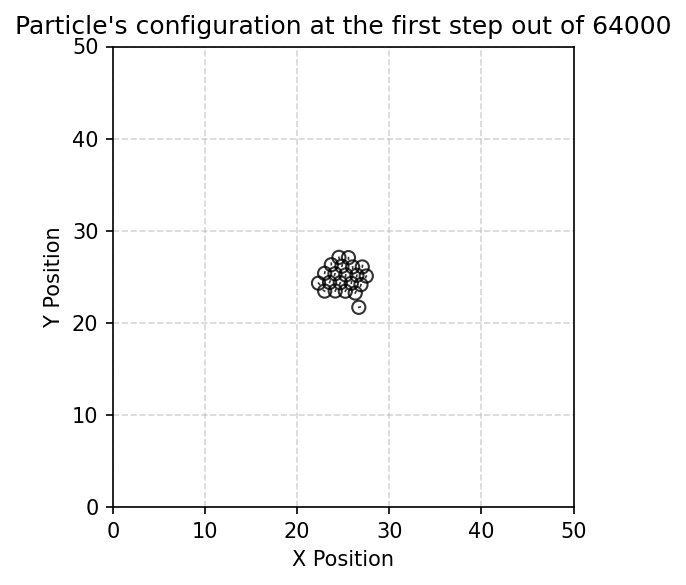

In [25]:
import numpy as np
import matplotlib.pyplot as plt
def plot_position_snapshot_aggregation(positions, shot=-1, area=50, color_p=False, radius=0.8):

    positions_data = positions['data']
    availble_shot = positions_data.shape[0]
    print('available steps: ', availble_shot, '\tchoosed step: ', shot)
    x = positions_data[shot, :, 0]
    y = positions_data[shot, :, 1]
    if positions_data.shape[2] == 3:
        phi = positions_data[shot, :, 2]
    fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
    if positions_data.shape[2] == 3:
        if color_p:
            scatter = ax.scatter(
                x, y, 
                s=radius*area,
                c=phi,
                cmap='twilight',
                alpha=0.8
            )
            cbar = fig.colorbar(scatter, ax=ax, label='Phi (radians)', orientation='vertical', shrink=0.8, pad=0.02)
            cbar.set_alpha(1)
        else:
            scatter = ax.scatter(
                x, y, 
                s=radius*area,
                edgecolors='black',
                facecolors='none',
                alpha=0.8
            )
            x_end = x + radius * np.cos(phi) *10/area 
            y_end = y + radius * np.sin(phi)*10/area

            for i in range(positions_data.shape[1]):
                ax.plot([x[i], x_end[i]], [y[i], y_end[i]], color='black', linewidth=0.8, alpha=0.8)
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    if shot == -1:
        ax.set_title(f"Particle's configuration at the last step out of {availble_shot}")
    elif shot == 0:
        ax.set_title(f"Particle's configuration at the first step out of {availble_shot}")
    else:
        ax.set_title(f"Particle's configuration at step {shot} out of {availble_shot}")
    ax.set_xlim(0, area)
    ax.set_ylim(0, area)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_position_snapshot_aggregation(positions, shot=0,area=50, color_p=False, radius=0.8)

Available steps: 64000 	Chosen step: 0


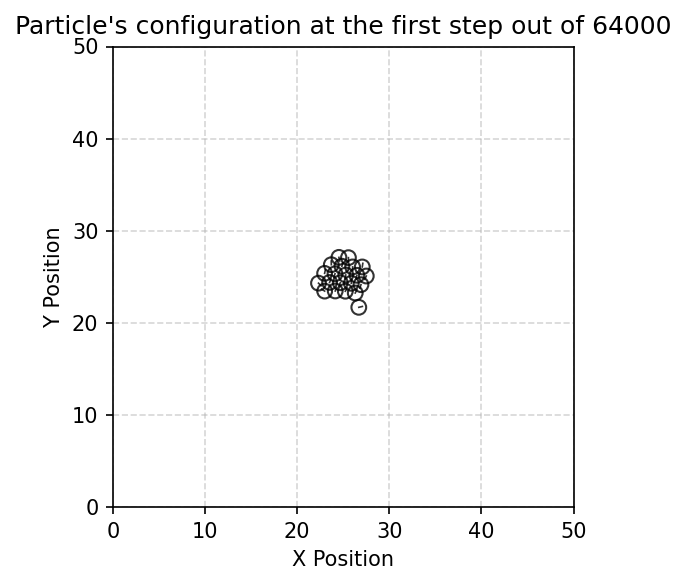

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_position_snapshot_aggregation(positions, shot=-1, area=50, radius=0.8):
    positions_data = positions['data']
    available_steps = positions_data.shape[0]
    print('Available steps:', available_steps, '\tChosen step:', shot)

    # Extract x and y positions
    x = positions_data[shot, :, 0]
    y = positions_data[shot, :, 1]
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
    
    # Plot a circle for each position using patches.Circle
    for xi, yi in zip(x, y):
        circle = patches.Circle((xi, yi), radius, edgecolor='black',
                                facecolor='none', alpha=0.8)
        ax.add_patch(circle)
    
    # Optionally, if you have an orientation (phi) and want to draw a line indicating direction:
    if positions_data.shape[2] == 3:
        phi = positions_data[shot, :, 2]
        # Draw lines from the center to the edge of the circle indicating direction
        for xi, yi, ph in zip(x, y, phi):
            x_end = xi + radius * np.cos(ph) * area /100
            y_end = yi + radius * np.sin(ph) * area /100
            ax.plot([xi, x_end], [yi, y_end], color='black', linewidth=0.8, alpha=0.8)
    
    # Set labels and title
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    if shot == -1:
        ax.set_title(f"Particle's configuration at the last step out of {available_steps}")
    elif shot == 0:
        ax.set_title(f"Particle's configuration at the first step out of {available_steps}")
    else:
        ax.set_title(f"Particle's configuration at step {shot} out of {available_steps}")

    ax.set_xlim(0, area)
    ax.set_ylim(0, area)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# Example usage:
# Assuming `positions` is a dict containing your positions data.
plot_position_snapshot_aggregation(positions, shot=0, area=50, radius=0.8)


In [ ]:
import numpy as np
import cv2

def draw_grid(frame, frame_size, area, grid_spacing=10, color=(200, 200, 200)):
    scale = frame_size / area
    spacing_pixels = int(grid_spacing * scale)

    for x in range(0, frame_size, spacing_pixels):
        cv2.line(frame, (x, 0), (x, frame_size), color, 1)

    for y in range(0, frame_size, spacing_pixels):
        cv2.line(frame, (0, y), (frame_size, y), color, 1)

def map_to_frame(x, y, frame_size, area):
    scale = frame_size / area
    return int(x * scale), int(frame_size - y * scale)

def animate_positions_opencv(positions, output_name, area=50, color_p=False, 
                             frame_skip=1, frame_size=800, fps=20, radius=0.8):
    positions_data = positions['data']
    num_steps = positions_data.shape[0]
    num_particles = positions_data.shape[1]
    has_phi = positions_data.shape[2] == 3

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_name, fourcc, fps, (frame_size, frame_size))

    # particle_radius = int(radius*area)  # Ensure visibility
    # particle_radius = max(1, particle_radius)
    particle_radius = int(radius * (frame_size / (area*2)))

    for step in range(0, num_steps, frame_skip):
        frame = np.ones((frame_size, frame_size, 3), dtype=np.uint8) * 255  # White background
        
        draw_grid(frame, frame_size, area, grid_spacing=10, color=(200, 200, 200))
        
        for i in range(num_particles):
            x, y = positions_data[step, i, :2]
            
            # Skip NaN values (particle not yet deposited)
            if np.isnan(x) or np.isnan(y):
                continue

            cx, cy = map_to_frame(x, y, frame_size, area)

            if has_phi:
                phi = positions_data[step, i, 2]
            
            # Draw circle with black outline and white fill
            cv2.circle(frame, (cx, cy), particle_radius, (0, 0, 0), 2, lineType=cv2.LINE_AA)
            cv2.circle(frame, (cx, cy), particle_radius - 1, (255, 255, 255), -1, lineType=cv2.LINE_AA)

            if has_phi and not color_p and not np.isnan(phi):
                # Draw direction line from center to end of radius
                x_end = x + radius * np.cos(phi)
                y_end = y + radius * np.sin(phi)

                # Skip NaN values in phi-based calculations
                if np.isnan(x_end) or np.isnan(y_end):
                    continue

                cx_end, cy_end = map_to_frame(x_end, y_end, frame_size, area)
                cv2.line(frame, (cx, cy), (cx_end, cy_end), (0, 0, 0), 2, lineType=cv2.LINE_AA)

        # Add text for step count
        text = f"Step {step}/{num_steps}"
        cv2.putText(frame, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2, lineType=cv2.LINE_AA)

        out.write(frame)

        if step % (50 * frame_skip) == 0:
            print(f"Processing frame {step}/{num_steps}")

    out.release()
    print("Video saved as", output_name)

animate_positions_opencv(positions, "T.15_t0.1.mp4", area=50, color_p=False, frame_skip=1, fps=60)


---

### Part 3: **||. Trajoctory and snapshots of system at specific temperatures**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def target_temperature_index (variable_name, target_temperature):
    data = variable_name['data']
    temperature_labels = variable_name['temperature label'].flatten()
    print(f"available temperatures are from {min(temperature_labels)} to {max(temperature_labels)}.")
          
    try:
        index = np.where(temperature_labels == target_temperature)[0][0]
    except IndexError:
        print(f"Target temperature {target_temperature} not found in temperature_labels.")
        return 0

    total_snapshots = data.shape[0]
    return int(total_snapshots / len(temperature_labels) * index)

def plot_trajectory(positions, target_temperature, step_window=10000):
    positions_data = positions['data']

    step_min = target_temperature_index(positions, target_temperature)
    step_max = step_min + step_window

    fig, ax = plt.subplots(1, 2, figsize=(8, 4), dpi=200)

    num_particles = positions_data.shape[1]

    for i in range(num_particles):
        ax[0].scatter(
            positions_data[step_min:step_max, i, 0], 
            positions_data[step_min:step_max, i, 1], 
            c=np.linspace(0, 1, step_max - step_min),
            cmap="plasma",
            s=0.02, alpha=0.6
        )

    ax[0].set_title(f"Trajectories at T={target_temperature} for {step_window} steps")
    ax[0].set_xlabel("X Position")
    ax[0].set_ylabel("Y Position")

    # Plot initial vs final positions
    ax[1].scatter(
        positions_data[step_min, :, 0], positions_data[step_min, :, 1], 
        marker='o', s=20, color='#00aabb', label='Initial Position'
    )
    ax[1].scatter(
        positions_data[step_max - 1, :, 0], positions_data[step_max - 1, :, 1], 
        marker='x', s=20, color='#ff7777', label='Final Position'
    )
    print("available steps: ", positions_data.shape[0])
    ax[1].set_title("Initial vs. Final Positions")
    ax[1].set_xlabel("X Position")
    ax[1].set_ylabel("Y Position")
    ax[1].legend()

    for ax_i in ax:
        ax_i.set_xlim(0,20)
        ax_i.set_ylim(0,20)
        ax_i.set_aspect('equal', adjustable='datalim')
        ax_i.grid(linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

def plot_snapshot_oriented(positions, target_temperature, color_palette='hsv'):
    positions_data = positions['data']
    shot = target_temperature_index(positions, target_temperature)

    fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
    
    scatter = ax.scatter(
        positions_data[shot, :, 0],    # X
        positions_data[shot, :, 1],    # Y
        c=positions_data[shot, :, 2],  # φ
        s=60,
        alpha=0.8,
        vmin=-np.pi,
        vmax=np.pi,
        cmap=color_palette
    )
        
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('φ in radian')
        
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.set_title(f'Positions + Orientation φ (T={target_temperature})')
    
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 20)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_snapshot_oriented_radius(positions, target_temperature, line_length=0.4):
    positions_data = positions['data']
    shot = target_temperature_index(positions, target_temperature)

    fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
    
    x = positions_data[shot, :, 0]
    y = positions_data[shot, :, 1]
    phi = positions_data[shot, :, 2]

    x_end = x + line_length * np.cos(phi)
    y_end = y + line_length * np.sin(phi)

    ax.scatter(
        x, y, 
        s=250,
        edgecolors='black',
        facecolors='none',
        alpha=0.8
    )

    for i in range(len(x)):
        ax.plot([x[i], x_end[i]], [y[i], y_end[i]], color='black', linewidth=0.8, alpha=0.8)

    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.set_title(f'Positions + Orientation φ (T={target_temperature})')
    
    ax.set_xlim(6, 20)
    ax.set_ylim(0, 12.5)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()


In [ ]:
plot_snapshot_oriented(positions, target_temperature=0.02, color_palette='twilight')


In [ ]:
plot_snapshot_oriented_radius(positions, target_temperature=0.02)


In [ ]:
plot_trajectory(positions, 0.6, step_window=3000000)

---

### Part 3: **Depiction of $\phi$ and $\Delta\phi$**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_hist_phi(positions, target_t, range_read=1000, bins_num=100):
    positions_data = positions['data']
    shot = target_temperature_index(positions, target_t)

    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'},figsize=(6, 4))

    ax.hist(positions_data[shot-range_read:shot+range_read,:,2].flatten(), bins=bins_num, color='#954965', alpha=0.79)
    ax.set_title(f'Histogram of particles $\phi$ over {range_read} steps, at T = {target_t}')
    ax.set_xlabel('Orientation Angle $\phi$ (rad)')
    ax.set_ylabel('Frequency')
    ax.set_axisbelow(True)
    ax.grid(color='gray', linestyle='dashed', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

def plot_delta_phi_hist(positions, target_t, min_dis, range_read=1000, bins_num= 100):
    index = target_temperature_index(positions, target_t)
    total_delta_phi = []
    
    for a in range(range_read):
        data = positions['data'][index+a]
        for i in range(data.shape[0]):
            for j in range(i+1, data.shape[0]):
                r = np.sqrt((data[i, 0] - data[j, 0])**2 + (data[i, 1] - data[j, 1])**2)
                if r < min_dis:
                    delta_phi = data[i, 2] - data[j, 2]
                    # total_delta_phi.append(delta_phi)
                    total_delta_phi.append((delta_phi + np.pi) % (2 * np.pi) - np.pi)

    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.hist(total_delta_phi, bins=bins_num, color='#55b3d1')

    ax.set_xlabel(r'$\Delta \phi$ (rad)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Histogram of $\Delta \phi$ over {range_read} steps, at T={target_t}')
    ax.set_axisbelow(True)
    ax.grid(color='gray', linestyle='dashed', alpha=0.5)

    plt.show()
    
def plot_hist_phi_polar(positions, target_t, range_read=1000, bins_num=100):
    positions_data = positions['data']
    shot = target_temperature_index(positions, target_t)

    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))

    phi_values = positions_data[shot-range_read:shot+range_read, :, 2].flatten()
    bins = np.linspace(-np.pi, np.pi, bins_num + 1)

    hist, bin_edges = np.histogram(phi_values, bins=bins)

    ax.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), color='#954965', alpha=0.79, align='edge')

    ax.set_title(f'Polar Histogram of $\phi$ at T = {target_t}')
    ax.set_theta_zero_location("E")
    plt.show()

def plot_delta_phi_hist_polar(positions, target_t, min_dis, range_read=1000, bins_num=100):
    index = target_temperature_index(positions, target_t)
    total_delta_phi = []

    for a in range(range_read):
        data = positions['data'][index + a]
        for i in range(data.shape[0]):
            for j in range(i + 1, data.shape[0]):
                r = np.sqrt((data[i, 0] - data[j, 0])**2 + (data[i, 1] - data[j, 1])**2)
                if r < min_dis:
                    delta_phi = data[i, 2] - data[j, 2]
                    delta_phi = (delta_phi + np.pi) % (2 * np.pi) - np.pi  # Wrap to [-π, π]
                    total_delta_phi.append(delta_phi)

    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))

    bins = np.linspace(-np.pi, np.pi, bins_num + 1)
    hist, bin_edges = np.histogram(total_delta_phi, bins=bins)

    ax.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), color='#55b3d1', align='edge')

    ax.set_title(f'Polar Histogram of $\Delta \phi$ at T={target_t}')
    ax.set_theta_zero_location("E")

    plt.show()


In [ ]:
plot_hist_phi(positions, 0.02)

In [ ]:
plot_hist_phi_polar(positions, 0.02, 1000)

In [ ]:
plot_delta_phi_hist(positions, 0.02, min_dis=50, range_read=1000, bins_num= 100)


In [ ]:
plot_delta_phi_hist_polar(positions, 0.02, min_dis=50, range_read=1000, bins_num= 100)


---

### Part 4: **Animation of particles movement**

In [ ]:
positions['data'].shape

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def map_to_frame(x, y, frame_size, offset=0):
    scale = frame_size / 20
    return int(x * scale + offset), int(y * scale + offset)

def phi_to_color(phi):
    norm_phi = phi / (2 * np.pi) 
    color = cm.twilight(norm_phi)
    bgr_color = (int(color[2] * 255), int(color[1] * 255), int(color[0] * 255))
    return bgr_color

def temperature_to_color(temp):
    norm_temp = (temp - 0.1) / (1 - 0.1)
    color = cm.coolwarm(norm_temp)
    bgr_color = (int(color[2] * 255), int(color[1] * 255), int(color[0] * 255))
    return bgr_color
    
def animation_particles(positions, output_name, phase_transition=False, frame_skip=1):
    frame_size = 800
    particle_radius = 10

    positions_data = positions['data']
    type_size = positions_data.shape[2]

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_name, fourcc, 10.0 / frame_skip, (frame_size + 200, frame_size))  # Adjust frame rate

    temperature_labels = positions['temperature label']
    high_temp = np.max(temperature_labels)
    low_temp = np.min(temperature_labels)
    num_frames = positions_data.shape[0]
    temperatures = np.linspace(high_temp, low_temp, num_frames // 2).tolist() + np.linspace(low_temp, high_temp, num_frames - num_frames // 2).tolist()

    for i in range(0, num_frames, frame_skip):  # Skip frames
        frame = np.ones((frame_size, frame_size + 200, 3), dtype=np.uint8) * 255

        # Draw bounding box around particles
        cv2.rectangle(frame, (0, 0), (frame_size, frame_size), (0, 0, 0), 2)

        # Draw particles
        for j in range(positions_data.shape[1]):  # Iterate over particles
            x = positions_data[i, j, 0]  # x-coordinate of particle j
            y = positions_data[i, j, 1]  # y-coordinate of particle j
            
            cx, cy = map_to_frame(x, y, frame_size)

            if type_size == 3:
                phi = positions_data[i, j, 2] + np.pi  # Use index 2 for phi
                color = phi_to_color(phi)
            else:
                color = (120, 120, 120)

            cv2.circle(frame, (cx, cy), particle_radius, color, -1)

        if phase_transition:
            # Draw temperature bar with gradient
            bar_x_start = frame_size + 50
            bar_x_end = frame_size + 150
            bar_y_start = 50
            bar_y_end = frame_size - 50
            for y_bar in range(bar_y_start, bar_y_end):
                t = (y_bar - bar_y_start) / (bar_y_end - bar_y_start)
                color = cm.coolwarm(1 - t)
                bgr_color = (int(color[2] * 255), int(color[1] * 255), int(color[0] * 255))
                cv2.line(frame, (bar_x_start, y_bar), (bar_x_end, y_bar), bgr_color, 1)

            # Draw indicator for current temperature
            temp = temperatures[i]
            indicator_y = int(bar_y_end - (temp - 0.1) / (1 - 0.1) * (bar_y_end - bar_y_start))
            cv2.arrowedLine(frame, (bar_x_end + 10, indicator_y), (bar_x_end + 50, indicator_y), (0, 0, 0), 2, tipLength=0.3)

        out.write(frame)

        if i % (50 * frame_skip) == 0:  # Adjust progress reporting
            print(f"Processing frame {i}/{num_frames} (skipping {frame_skip - 1} frames)")

    out.release()
    print("Video saved as", output_name)

    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title("Particle Movement at Last Frame")
    plt.show()

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm import tqdm  # For progress bar

def map_to_frame(x, y, frame_size, offset=0):
    """Map particle coordinates to frame coordinates."""
    scale = frame_size / 20
    return int(x * scale + offset), int(y * scale + offset)

def phi_to_color(phi):
    """Convert phase angle to a color using the twilight colormap."""
    norm_phi = phi / (2 * np.pi) 
    color = cm.twilight(norm_phi)
    return (int(color[2] * 255), int(color[1] * 255), int(color[0] * 255))

def temperature_to_color(temp, low_temp=0.1, high_temp=1.0):
    """Convert temperature to a color using the coolwarm colormap."""
    norm_temp = (temp - low_temp) / (high_temp - low_temp)
    color = cm.coolwarm(norm_temp)
    return (int(color[2] * 255), int(color[1] * 255), int(color[0] * 255))

def draw_particles(frame, frame_data, frame_size, particle_radius, type_size):
    """Draw particles on the frame."""
    for j in range(frame_data.shape[0]):  # Iterate over particles
        x, y = frame_data[j, 0], frame_data[j, 1]
        cx, cy = map_to_frame(x, y, frame_size)
        if type_size == 3:
            phi = frame_data[j, 2] + np.pi
            color = phi_to_color(phi)
        else:
            color = (120, 120, 120)  # Default gray color
        cv2.circle(frame, (cx, cy), particle_radius, color, -1)

def draw_temperature_bar(frame, frame_size, current_temp, low_temp, high_temp):
    """Draw the temperature bar and indicator."""
    bar_x_start = frame_size + 50
    bar_x_end = frame_size + 150
    bar_y_start = 50
    bar_y_end = frame_size - 50

    # Draw gradient bar
    for y_bar in range(bar_y_start, bar_y_end):
        t = (y_bar - bar_y_start) / (bar_y_end - bar_y_start)
        color = temperature_to_color(high_temp - t * (high_temp - low_temp), low_temp, high_temp)
        cv2.line(frame, (bar_x_start, y_bar), (bar_x_end, y_bar), color, 1)

    # Draw temperature indicator
    indicator_y = int(bar_y_end - (current_temp - low_temp) / (high_temp - low_temp) * (bar_y_end - bar_y_start))
    cv2.arrowedLine(frame, (bar_x_end + 10, indicator_y), (bar_x_end + 50, indicator_y), (0, 0, 0), 2, tipLength=0.3)

def create_frame(frame_size):
    """Create a blank frame with a bounding box."""
    frame = np.ones((frame_size, frame_size + 200, 3), dtype=np.uint8) * 255
    cv2.rectangle(frame, (0, 0), (frame_size, frame_size), (0, 0, 0), 2)
    return frame

def animation_particles(positions, output_name, phase_transition=False, frame_skip=1):
    """Generate an animation of particle movement."""
    frame_size = 800
    particle_radius = 10

    # Validate input data
    if 'data' not in positions:
        raise ValueError("Input data must contain 'data' key.")
    positions_data = positions['data']
    type_size = positions_data.shape[2]

    # Initialize video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_name, fourcc, 10.0 / frame_skip, (frame_size + 200, frame_size))

    # Temperature settings
    temperature_labels = positions['temperature label']
    high_temp, low_temp = np.max(temperature_labels), np.min(temperature_labels)
    num_frames = positions_data.shape[0]
    temperatures = np.linspace(high_temp, low_temp, num_frames // 2).tolist() + np.linspace(low_temp, high_temp, num_frames - num_frames // 2).tolist()

    # Process frames
    for i in tqdm(range(0, num_frames, frame_skip), desc="Processing frames"):
        frame = create_frame(frame_size)
        draw_particles(frame, positions_data[i], frame_size, particle_radius, type_size)
        if phase_transition:
            draw_temperature_bar(frame, frame_size, temperatures[i], low_temp, high_temp)
        out.write(frame)

    out.release()
    print(f"Video saved as {output_name}")

    # Display the last frame
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title("Particle Movement at Last Frame")
    plt.show()

In [ ]:
animation_particles(positions, output_name="particle_animation.mp4", phase_transition=True, frame_skip=500)